# Import

In [713]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import f1_score
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import warnings
from hillclimbers import climb_hill, partial
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedKFold

In [714]:
loan_train = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/train.csv', index_col='id')
loan_test = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/test.csv', index_col='id')
credit_risk = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/credit_risk_dataset.csv')

In [715]:
loan_train = pd.concat([loan_train,credit_risk], axis=0, ignore_index=True)

# Discovering

In [716]:
loan_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91226 entries, 0 to 91225
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  91226 non-null  int64  
 1   person_income               91226 non-null  int64  
 2   person_home_ownership       91226 non-null  object 
 3   person_emp_length           90331 non-null  float64
 4   loan_intent                 91226 non-null  object 
 5   loan_grade                  91226 non-null  object 
 6   loan_amnt                   91226 non-null  int64  
 7   loan_int_rate               88110 non-null  float64
 8   loan_percent_income         91226 non-null  float64
 9   cb_person_default_on_file   91226 non-null  object 
 10  cb_person_cred_hist_length  91226 non-null  int64  
 11  loan_status                 91226 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 8.4+ MB


In [717]:
loan_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
loan_status                      0
dtype: int64

In [718]:
loan_train['person_emp_length'].fillna(loan_train['person_emp_length'].median(), inplace=True)
loan_train['loan_int_rate'].fillna(loan_train['loan_int_rate'].median(), inplace=True)

In [719]:
loan_train.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [720]:
loan_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [721]:
loan_train['person_home_ownership'].unique()

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [722]:
loan_train['loan_intent'].unique()

array(['EDUCATION', 'MEDICAL', 'PERSONAL', 'VENTURE', 'DEBTCONSOLIDATION',
       'HOMEIMPROVEMENT'], dtype=object)

In [723]:
loan_train['loan_grade'].unique()

array(['B', 'C', 'A', 'D', 'E', 'F', 'G'], dtype=object)

In [724]:
cat_col1 = [x for x in loan_train.columns if loan_train[x].dtype=='object']
cat_col1

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [725]:
loan_train['loan_status'].unique()

array([0, 1])

In [726]:
loan_train['loan_status'].value_counts()

loan_status
0    75768
1    15458
Name: count, dtype: int64

## Cat_col

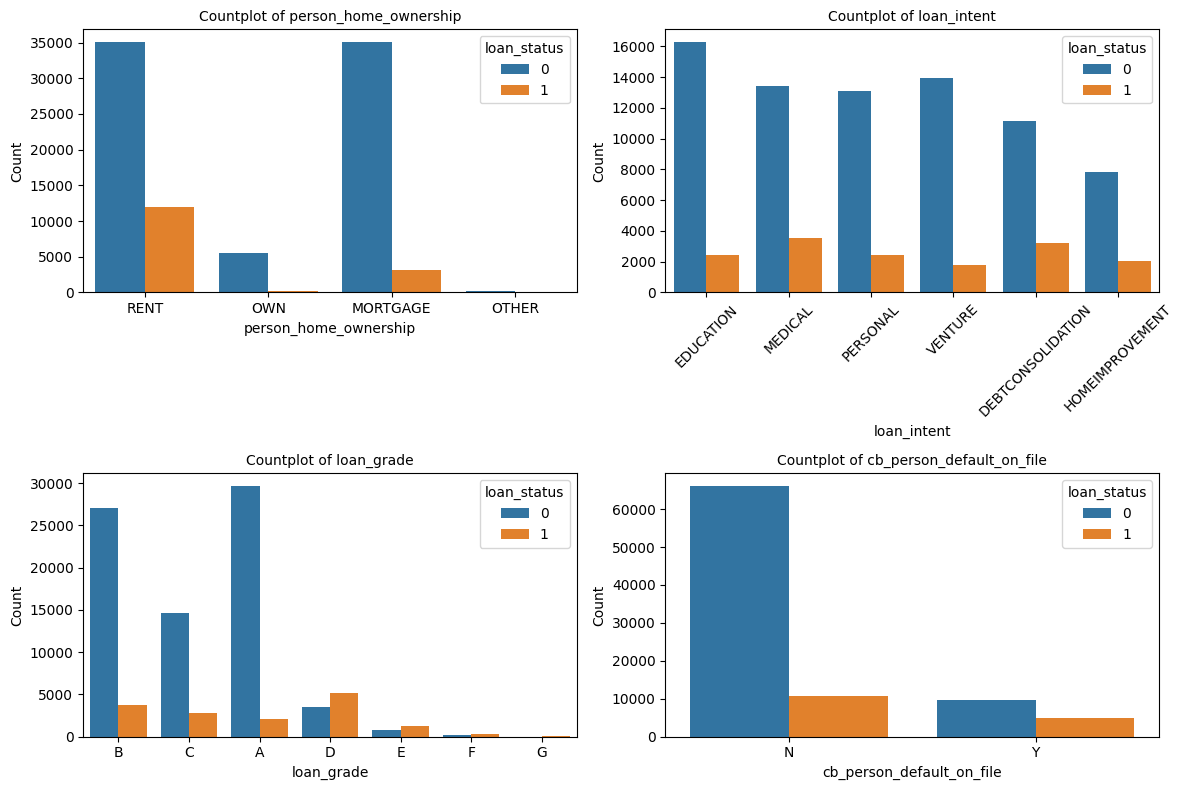

In [727]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

for feat, ax in zip(cat_col1, axs.ravel()):
    sns.countplot(data=loan_train, x=feat, hue='loan_status', ax=ax)
    ax.set_title(f"Countplot of {feat}", size=10)
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    if feat == "loan_intent":
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
plt.tight_layout()
plt.show()

## loan_percent_income

<Axes: >

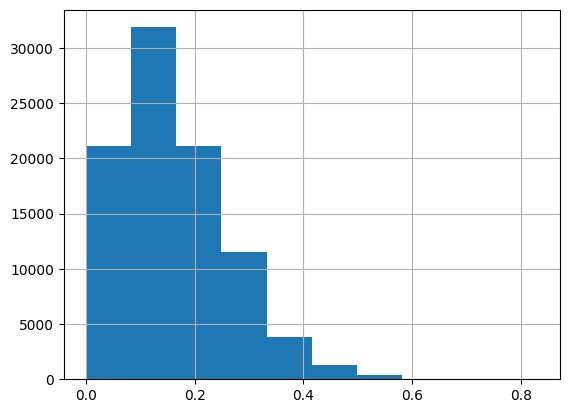

In [728]:
loan_train['loan_percent_income'].hist()

In [729]:
loan_train[loan_train['loan_percent_income']>0.5].shape

(287, 12)

In [730]:
'''loan_train.drop(loan_train[loan_train['loan_percent_income']>0.5].index, inplace=True)'''

"loan_train.drop(loan_train[loan_train['loan_percent_income']>0.5].index, inplace=True)"

## person_income

<Axes: >

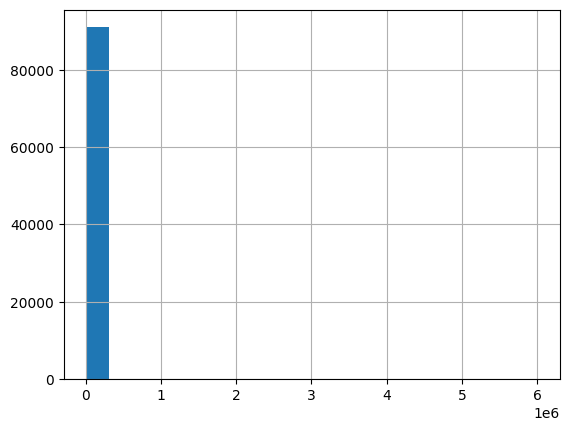

In [731]:
loan_train['person_income'].hist(bins=20)

In [732]:
loan_train[loan_train['person_income']>=300000].shape

(252, 12)

In [733]:
'''loan_train.drop(loan_train[loan_train['person_income']>=300000].index, inplace=True)'''

"loan_train.drop(loan_train[loan_train['person_income']>=300000].index, inplace=True)"

## person_emp_length

In [734]:
'''loan_train[loan_train['person_emp_length']>=28].shape'''

"loan_train[loan_train['person_emp_length']>=28].shape"

In [735]:
'''loan_train.drop(loan_train[loan_train['person_emp_length']>=28].index, inplace=True)'''

"loan_train.drop(loan_train[loan_train['person_emp_length']>=28].index, inplace=True)"

## cb_person_cred_hist_length

In [736]:
'''loan_train.drop(loan_train[loan_train['cb_person_cred_hist_length']>=18].index, inplace=True)'''

"loan_train.drop(loan_train[loan_train['cb_person_cred_hist_length']>=18].index, inplace=True)"

# Features engineer

## LabelEncoder

In [737]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [738]:
def encode_note(array):
    array=le.fit_transform(array)
    keys = le.classes_
    values = le.transform(le.classes_)
    dictionary = dict(zip(keys, values))
    print(dictionary)
    return array

In [739]:
cat_col2 = ['person_home_ownership',
 'loan_grade',
 'cb_person_default_on_file']

In [740]:
def label(df):
    for x in cat_col1:
        df[x]= encode_note(df[[x]])
    return df

In [741]:
loan_train = label(loan_train)

{'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'N': 0, 'Y': 1}


# ________

In [742]:
loan_x_train = loan_train.drop(columns='loan_status')
loan_y_train = loan_train['loan_status']
loan_x_train

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,3,0.0,1,1,6000,11.49,0.17,0,14
1,22,56000,2,6.0,3,2,4000,13.35,0.07,0,2
2,29,28800,2,8.0,4,0,6000,8.90,0.21,0,10
3,30,70000,3,14.0,5,1,12000,11.11,0.17,0,5
4,22,60000,3,2.0,3,0,6000,6.92,0.10,0,3
...,...,...,...,...,...,...,...,...,...,...,...
91221,57,53000,0,1.0,4,2,5800,13.16,0.11,0,30
91222,54,120000,0,4.0,4,0,17625,7.49,0.15,0,19
91223,65,76000,3,3.0,2,1,35000,10.99,0.46,0,28
91224,56,150000,0,5.0,4,1,15000,11.48,0.10,0,26


# _________________


# Important Feature

<Axes: >

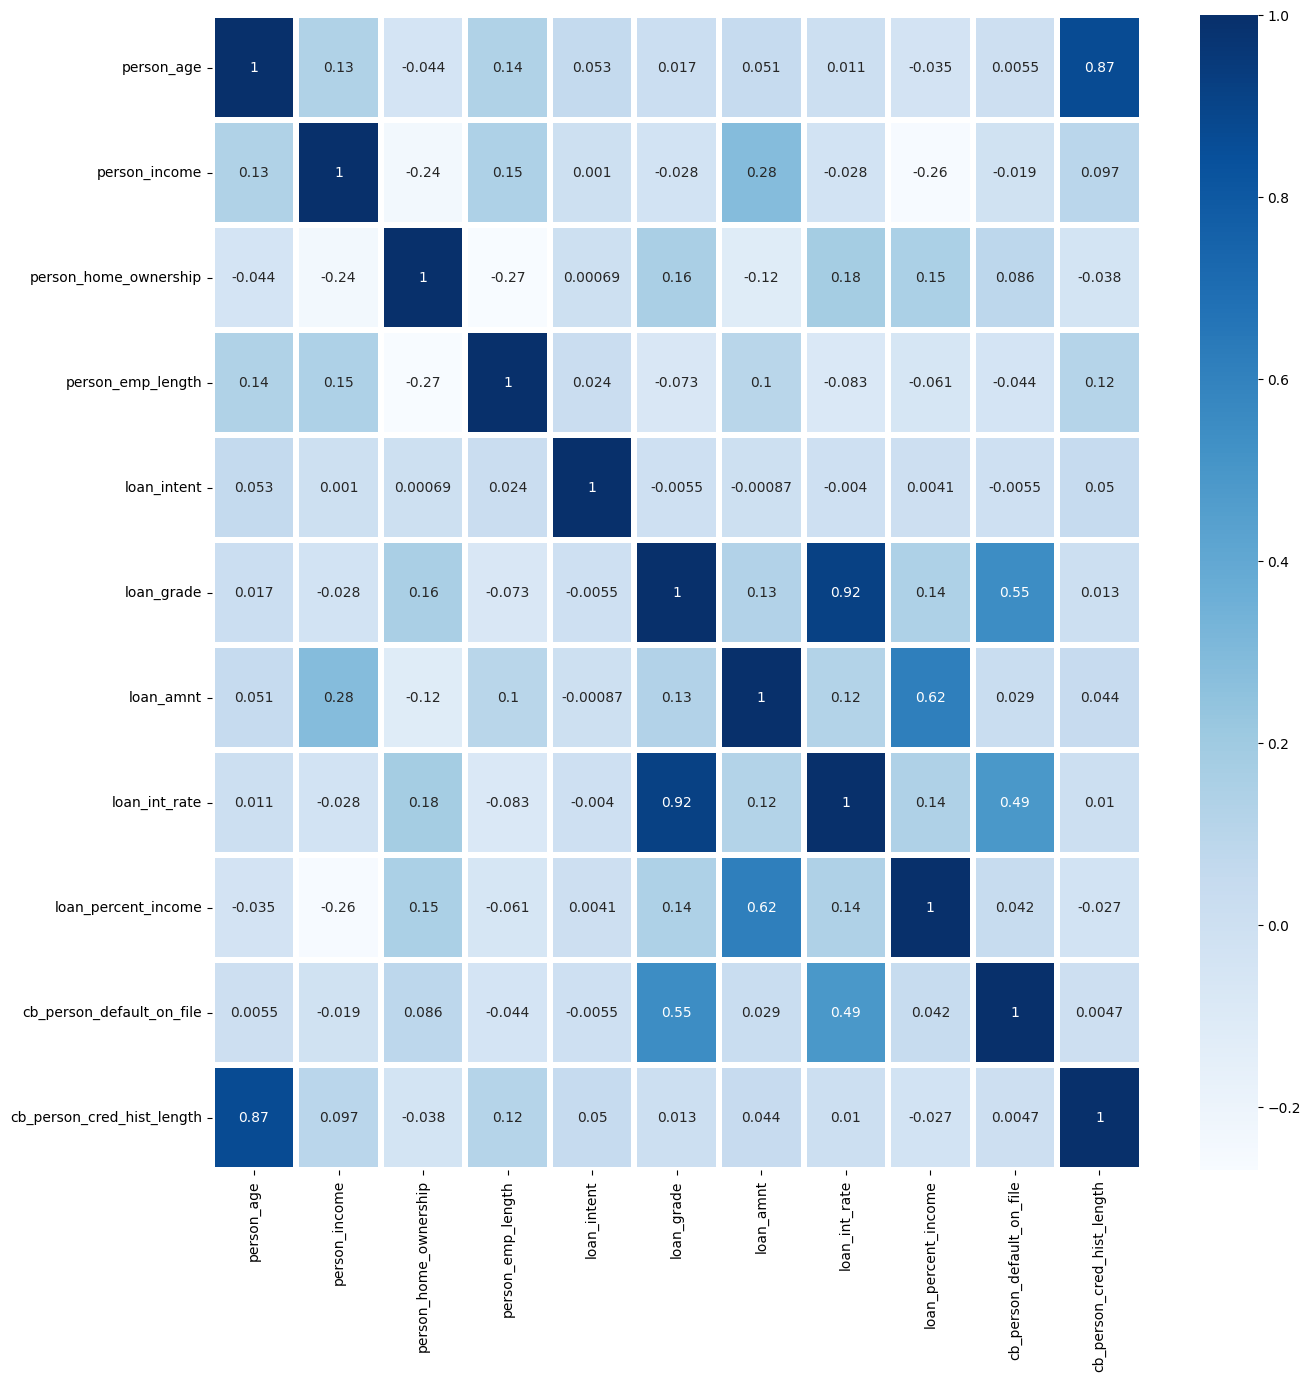

In [743]:
plt.figure(figsize=(15,15))
sns.heatmap(loan_x_train.corr(), cmap='Blues' ,linewidths= 3,annot = True)

In [744]:
rf_feature = RandomForestClassifier()
rf_feature.fit(loan_x_train,loan_y_train)

RandomForestClassifier()

<Axes: >

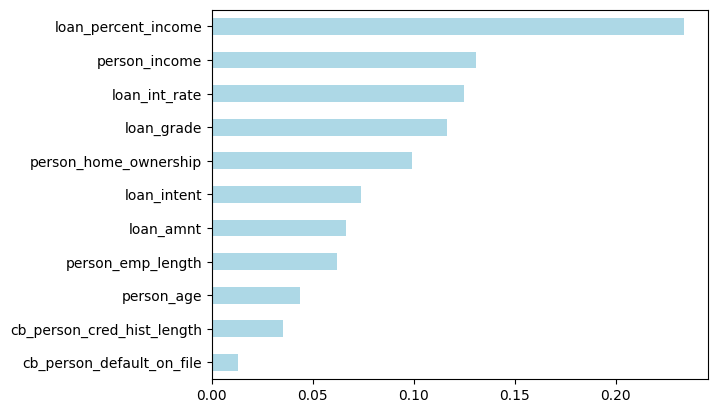

In [745]:
important_rf = pd.Series(rf_feature.feature_importances_, index=loan_x_train.columns).sort_values()
important_rf.plot(kind='barh', color='lightblue')

# Model Building

In [746]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

## Preprocessing

In [747]:
def score_(model):
    X_train, X_test, y_train, y_test = train_test_split(loan_x_train, loan_y_train, stratify=loan_y_train, shuffle=True, test_size=0.2, random_state=42)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(metrics.classification_report(y_test,y_pred))
    y_pred_prop = model.predict_proba(X_test)[:,1]
    print(roc_auc_score(y_test,y_pred_prop))
    print(f1_score(y_pred,y_test))

### Over_sampling SMOTE

In [748]:
'''from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=0,k_neighbors=2)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
y_sm.value_counts()'''

'from imblearn.over_sampling import SMOTE\n\nsm = SMOTE(random_state=0,k_neighbors=2)\nX_sm, y_sm = sm.fit_resample(X_train, y_train)\ny_sm.value_counts()'

## TUNING

In [749]:
'''skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(loan_x_train, loan_y_train)):
    X_train, X_test = loan_x_train.iloc[train_idx], loan_x_train.iloc[test_idx]
    y_train, y_test = loan_y_train.iloc[train_idx], loan_y_train.iloc[test_idx]'''

'skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)\nfor fold_idx, (train_idx, test_idx) in enumerate(skf.split(loan_x_train, loan_y_train)):\n    X_train, X_test = loan_x_train.iloc[train_idx], loan_x_train.iloc[test_idx]\n    y_train, y_test = loan_y_train.iloc[train_idx], loan_y_train.iloc[test_idx]'

### RF

In [750]:
'''def objective(trial):

    params = {'n_estimators' : trial.suggest_int("n_estimators", 10, 200),
                'max_depth' : trial.suggest_int("max_depth", 1, 30),
                'min_samples_split' : trial.suggest_int("min_samples_split", 2, 10),
                'min_samples_leaf' : trial.suggest_int("min_samples_leaf", 1, 10),
                'max_features' : trial.suggest_categorical("max_features", ["sqrt", "log2"])
                }



    X_train, X_test, y_train, y_test = train_test_split(loan_x_train, loan_y_train, stratify=loan_y_train, shuffle=True, test_size=0.2)
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_pred_proba)

    return score

study = optuna.create_study(sampler=optuna.samplers.TPESampler(n_startup_trials=30, multivariate=True, seed=42), direction='maximize')'''

'def objective(trial):\n\n    params = {\'n_estimators\' : trial.suggest_int("n_estimators", 10, 200),\n                \'max_depth\' : trial.suggest_int("max_depth", 1, 30),\n                \'min_samples_split\' : trial.suggest_int("min_samples_split", 2, 10),\n                \'min_samples_leaf\' : trial.suggest_int("min_samples_leaf", 1, 10),\n                \'max_features\' : trial.suggest_categorical("max_features", ["sqrt", "log2"])\n                }\n\n\n\n    X_train, X_test, y_train, y_test = train_test_split(loan_x_train, loan_y_train, stratify=loan_y_train, shuffle=True, test_size=0.2)\n    model = RandomForestClassifier(**params)\n    model.fit(X_train, y_train)\n\n    y_pred_proba = model.predict_proba(X_test)[:,1]\n    score = roc_auc_score(y_test, y_pred_proba)\n\n    return score\n\nstudy = optuna.create_study(sampler=optuna.samplers.TPESampler(n_startup_trials=30, multivariate=True, seed=42), direction=\'maximize\')'

In [751]:
'''best_rf_param = {'n_estimators': 190,
 'max_depth': 30,
 'min_samples_split': 9,
 'min_samples_leaf': 5,
 'max_features': 'sqrt'}
rf = RandomForestClassifier(**best_rf_param)'''


"best_rf_param = {'n_estimators': 190,\n 'max_depth': 30,\n 'min_samples_split': 9,\n 'min_samples_leaf': 5,\n 'max_features': 'sqrt'}\nrf = RandomForestClassifier(**best_rf_param)"

### Catboost

In [752]:
'''def objective(trial):
    # Define hyperparameters to tune
    loss_function = 'Logloss'
    eval_metric = 'AUC'
    random_seed = 42

    # Suggest hyperparameters
    depth = trial.suggest_int('depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    iterations = trial.suggest_int('iterations', 10, 1000)
    reg_lambda = trial.suggest_float('reg_lambda', 1e-2, 10, log=True)
    subsample = trial.suggest_float('subsample', 0.25, 1.0)
    min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 5, 100)
    colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.05, 1.0)

    # Create and train the CatBoost model
    model_cat = CatBoostClassifier(
        loss_function=loss_function,
        eval_metric=eval_metric,
        random_seed=random_seed,
        depth=depth,
        learning_rate=learning_rate,
        iterations=iterations,
        reg_lambda=reg_lambda,
        subsample=subsample,
        min_data_in_leaf=min_data_in_leaf,
        colsample_bylevel=colsample_bylevel,
        verbose=0  # Turn off verbose for cleaner output during tuning
    )
    
    # Train the model
    model_cat.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100, verbose=False)

    # Make predictions
    y_pred_prob = model_cat.predict_proba(X_test)[:, 1]

    # Evaluate model using ROC AUC score
    auc = roc_auc_score(y_test, y_pred_prob)
    return auc

# Create Optuna study and optimize
study = optuna.create_study(direction='maximize')
'''

"def objective(trial):\n    # Define hyperparameters to tune\n    loss_function = 'Logloss'\n    eval_metric = 'AUC'\n    random_seed = 42\n\n    # Suggest hyperparameters\n    depth = trial.suggest_int('depth', 2, 10)\n    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)\n    iterations = trial.suggest_int('iterations', 10, 1000)\n    reg_lambda = trial.suggest_float('reg_lambda', 1e-2, 10, log=True)\n    subsample = trial.suggest_float('subsample', 0.25, 1.0)\n    min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 5, 100)\n    colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.05, 1.0)\n\n    # Create and train the CatBoost model\n    model_cat = CatBoostClassifier(\n        loss_function=loss_function,\n        eval_metric=eval_metric,\n        random_seed=random_seed,\n        depth=depth,\n        learning_rate=learning_rate,\n        iterations=iterations,\n        reg_lambda=reg_lambda,\n        subsample=subsample,\n        min_data_in

In [753]:
'''def objective(trial):
    
    params = {"loss_function": "Logloss",
              "eval_metric": "AUC",
              "verbose": False,
              "random_seed": 42,
              "depth": trial.suggest_int("depth", 2, 10),
              "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
              "iterations": trial.suggest_int("iterations", 10, 1000),
              "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10, log=True),
              "subsample": trial.suggest_float("subsample", 0.25, 1.0),
              "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 100),
              "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.05, 1.0)
             }

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, verbose=False)

    y_pred_proba = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_pred_proba)

    return score

study = optuna.create_study(sampler=optuna.samplers.TPESampler(n_startup_trials=30, multivariate=True, seed=42), direction='maximize')'''

'def objective(trial):\n    \n    params = {"loss_function": "Logloss",\n              "eval_metric": "AUC",\n              "verbose": False,\n              "random_seed": 42,\n              "depth": trial.suggest_int("depth", 2, 10),\n              "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),\n              "iterations": trial.suggest_int("iterations", 10, 1000),\n              "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10, log=True),\n              "subsample": trial.suggest_float("subsample", 0.25, 1.0),\n              "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 100),\n              "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.05, 1.0)\n             }\n\n    model = CatBoostClassifier(**params)\n    model.fit(X_train, y_train, verbose=False)\n\n    y_pred_proba = model.predict_proba(X_test)[:,1]\n    score = roc_auc_score(y_test, y_pred_proba)\n\n    return score\n\nstudy = optuna.create_study(sampler=optu

In [754]:
'''study.optimize(objective, n_trials=100)'''

'study.optimize(objective, n_trials=100)'

In [755]:
'''study.best_params'''

'study.best_params'

In [756]:
'''optuna.visualization.plot_optimization_history(study)'''

'optuna.visualization.plot_optimization_history(study)'

In [757]:
'''best_param_cat = {'depth': 4,
 'learning_rate': 0.253816597083723,
 'iterations': 906,
 'reg_lambda': 1.9656801862436566,
 'subsample': 0.9556676457731692,
 'min_data_in_leaf': 40,
 'colsample_bylevel': 0.8996801058383794}'''

"best_param_cat = {'depth': 4,\n 'learning_rate': 0.253816597083723,\n 'iterations': 906,\n 'reg_lambda': 1.9656801862436566,\n 'subsample': 0.9556676457731692,\n 'min_data_in_leaf': 40,\n 'colsample_bylevel': 0.8996801058383794}"

### XGBoost

In [758]:
'''# Hàm mục tiêu để hypertuning
def objective(trial):

    # Các hyperparameter cần tối ưu
    param = {
        'objective': 'binary:logistic',  # Phân loại nhị phân
        'tree_method': 'auto',  # Phương pháp xây dựng cây quyết định
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),  # L2 regularization
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),    # L1 regularization
        'eta': trial.suggest_float('eta', 0.01, 0.3),  # Learning rate
        'gamma': trial.suggest_float('gamma', 0, 10),  # Minimum loss reduction
        'max_depth': trial.suggest_int('max_depth', 3, 9),  # Độ sâu tối đa của cây
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Min child weight
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # Tỷ lệ dữ liệu sử dụng
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # Tỷ lệ đặc trưng sử dụng
    }
    
    # Huấn luyện mô hình
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    
    # Dự đoán trên tập kiểm tra (xác suất cho lớp dương)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Đánh giá mô hình bằng ROC AUC score
    auc = roc_auc_score(y_test, y_pred_prob)
    
    # Trả về AUC để Optuna tối ưu (maximize)
    return auc

# Tạo study để tối ưu hyperparameter
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# In ra hyperparameter tốt nhất
print("Best trial:")
trial = study.best_trial
print(f"  AUC: {trial.value}")
print(f"  Best hyperparameters: {trial.params}")
'''

'# Hàm mục tiêu để hypertuning\ndef objective(trial):\n\n    # Các hyperparameter cần tối ưu\n    param = {\n        \'objective\': \'binary:logistic\',  # Phân loại nhị phân\n        \'tree_method\': \'auto\',  # Phương pháp xây dựng cây quyết định\n        \'lambda\': trial.suggest_float(\'lambda\', 1e-8, 1.0, log=True),  # L2 regularization\n        \'alpha\': trial.suggest_float(\'alpha\', 1e-8, 1.0, log=True),    # L1 regularization\n        \'eta\': trial.suggest_float(\'eta\', 0.01, 0.3),  # Learning rate\n        \'gamma\': trial.suggest_float(\'gamma\', 0, 10),  # Minimum loss reduction\n        \'max_depth\': trial.suggest_int(\'max_depth\', 3, 9),  # Độ sâu tối đa của cây\n        \'min_child_weight\': trial.suggest_int(\'min_child_weight\', 1, 10),  # Min child weight\n        \'subsample\': trial.suggest_float(\'subsample\', 0.5, 1.0),  # Tỷ lệ dữ liệu sử dụng\n        \'colsample_bytree\': trial.suggest_float(\'colsample_bytree\', 0.5, 1.0),  # Tỷ lệ đặc trưng sử dụng\n  

In [759]:
'''best_param_XGC ={'lambda': 0.652082368412703, 
                 'alpha': 0.003236433392972551, 
                 'eta': 0.13477009474183235, 
                 'gamma': 0.5983442858947691, 
                 'max_depth': 8, 
                 'min_child_weight': 4, 
                 'subsample': 0.9684333306728039, 
                 'colsample_bytree': 0.816775335365089}'''

"best_param_XGC ={'lambda': 0.652082368412703, \n                 'alpha': 0.003236433392972551, \n                 'eta': 0.13477009474183235, \n                 'gamma': 0.5983442858947691, \n                 'max_depth': 8, \n                 'min_child_weight': 4, \n                 'subsample': 0.9684333306728039, \n                 'colsample_bytree': 0.816775335365089}"

### LGBMClassifier

In [760]:
'''import lightgbm as lgb


# Giả sử X và y đã có sẵn là dữ liệu của bạn (X là features, y là labels)

def objective(trial):
    # Define the hyperparameter space
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-5, 0.1)
    }

    
    # Create LGBMClassifier with suggested hyperparameters
    model = lgb.LGBMClassifier(**param)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict probabilities for validation set
    y_pred = model.predict_proba(X_test)[:, 1]
    
    # Compute AUC score
    auc = roc_auc_score(y_test, y_pred)
    
    return auc

# Tạo study để tối ưu hyperparameter
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# In ra hyperparameter tốt nhất
print("Best trial:")
trial = study.best_trial
print(f"  AUC: {trial.value}")
print(f"  Best hyperparameters: {trial.params}")
'''

'import lightgbm as lgb\n\n\n# Giả sử X và y đã có sẵn là dữ liệu của bạn (X là features, y là labels)\n\ndef objective(trial):\n    # Define the hyperparameter space\n    param = {\n        \'objective\': \'binary\',\n        \'metric\': \'auc\',\n        \'boosting_type\': \'gbdt\',\n        \'lambda_l1\': trial.suggest_loguniform(\'lambda_l1\', 1e-8, 10.0),\n        \'lambda_l2\': trial.suggest_loguniform(\'lambda_l2\', 1e-8, 10.0),\n        \'num_leaves\': trial.suggest_int(\'num_leaves\', 2, 256),\n        \'feature_fraction\': trial.suggest_uniform(\'feature_fraction\', 0.4, 1.0),\n        \'bagging_fraction\': trial.suggest_uniform(\'bagging_fraction\', 0.4, 1.0),\n        \'bagging_freq\': trial.suggest_int(\'bagging_freq\', 1, 7),\n        \'min_child_samples\': trial.suggest_int(\'min_child_samples\', 5, 100),\n        \'learning_rate\': trial.suggest_loguniform(\'learning_rate\', 1e-5, 0.1)\n    }\n\n    \n    # Create LGBMClassifier with suggested hyperparameters\n    model

In [761]:
'''print("Best trial:")
trial = study.best_trial
print(f"  AUC: {trial.value}")
print(f"  Best hyperparameters: {trial.params}")'''

'print("Best trial:")\ntrial = study.best_trial\nprint(f"  AUC: {trial.value}")\nprint(f"  Best hyperparameters: {trial.params}")'

In [762]:
best_param_lgbm = {'lambda_l1': 0.11736348482100109, 
                   'lambda_l2': 0.4710477421536297, 
                   'num_leaves': 107, 
                   'feature_fraction': 0.6521729535441277, 
                   'bagging_fraction': 0.9986235969117967, 
                   'bagging_freq': 4, 
                   'min_child_samples': 10, 
                   'learning_rate': 0.08135862604887588}

## AFTER TUNING

In [763]:
def fit_predict(model):
    loan_test = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/test.csv', index_col='id'))
    train = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/df_copy.csv'))
    X = train.drop(columns=['loan_status'])
    y = train['loan_status']

    original = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/credit_risk_dataset.csv'))
    original['person_emp_length'].fillna(original['person_emp_length'].median(), inplace=True)
    original['loan_int_rate'].fillna(original['loan_int_rate'].median(), inplace=True)
    X_original = original.drop(columns='loan_status')
    y_original = original['loan_status']

    scores = []
    oof_pred_probs = np.zeros((X.shape[0], len(np.unique(y))))
    test_pred_probs = np.zeros((loan_test.shape[0], len(np.unique(y))))

    skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        '''X_train = pd.concat([X_train, X_original], ignore_index=True)
        y_train = pd.concat([y_train, y_original], ignore_index=True)'''
        model.fit(X_train,y_train)

        y_pred_probs = model.predict_proba(X_test)
        oof_pred_probs[test_idx] = y_pred_probs

        temp_test_pred_probs = model.predict_proba(loan_test)
        test_pred_probs += temp_test_pred_probs / 5

        score = roc_auc_score(y_test,y_pred_probs[:,1])
        scores.append(score)

    return oof_pred_probs[:,1], test_pred_probs[:, 1], scores


In [764]:
def fit_predict_4cat(model):
    loan_test = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/test.csv', index_col='id')
    train = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/df_copy.csv')
    original = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/credit_risk_dataset.csv')
    original['person_emp_length'].fillna(original['person_emp_length'].median(), inplace=True)
    original['loan_int_rate'].fillna(original['loan_int_rate'].median(), inplace=True)
   
    
    categorical_columns = loan_test.columns.tolist()
    train[categorical_columns] = train[categorical_columns].astype(str).astype("category")
    loan_test[categorical_columns] = loan_test[categorical_columns].astype(str).astype("category")
    original[categorical_columns] = original[categorical_columns].astype(str).astype("category")

    X_original = original.drop(columns='loan_status')
    y_original = original['loan_status'] 
    X = train.drop(columns=['loan_status'])
    y = train['loan_status']
    scores = []
    oof_pred_probs = np.zeros((X.shape[0], len(np.unique(y))))
    test_pred_probs = np.zeros((loan_test.shape[0], len(np.unique(y))))

    skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        '''X_train = pd.concat([X_train, X_original], ignore_index=True)
        y_train = pd.concat([y_train, y_original], ignore_index=True)'''
        model.fit(X_train,y_train, cat_features=categorical_columns)

        y_pred_probs = model.predict_proba(X_test)
        oof_pred_probs[test_idx] = y_pred_probs

        temp_test_pred_probs = model.predict_proba(loan_test)
        test_pred_probs += temp_test_pred_probs / 5

        score = roc_auc_score(y_test,y_pred_probs[:,1])
        scores.append(score)

    return oof_pred_probs[:,1], test_pred_probs[:, 1], scores


In [765]:
scores = {}
oof_pred_probs = {}
test_pred_probs = {}

In [766]:
best_rf_param = {'n_estimators': 190,
 'max_depth': 30,
 'min_samples_split': 9,
 'min_samples_leaf': 5,
 'max_features': 'sqrt'}

cb_best_params = {'depth': 4,
 'learning_rate': 0.253816597083723,
 'iterations': 906,
 'reg_lambda': 1.9656801862436566,
 'subsample': 0.9556676457731692,
 'min_data_in_leaf': 40,
 'colsample_bylevel': 0.8996801058383794}

xgb_best_params ={'lambda': 0.652082368412703, 
                 'alpha': 0.003236433392972551, 
                 'eta': 0.13477009474183235, 
                 'gamma': 0.5983442858947691, 
                 'max_depth': 8, 
                 'min_child_weight': 4, 
                 'subsample': 0.9684333306728039, 
                 'colsample_bytree': 0.816775335365089}

lgbm_best_params = {'lambda_l1': 0.11736348482100109, 
                   'lambda_l2': 0.4710477421536297, 
                   'num_leaves': 107, 
                   'feature_fraction': 0.6521729535441277, 
                   'bagging_fraction': 0.9986235969117967, 
                   'bagging_freq': 4, 
                   'min_child_samples': 10, 
                   'learning_rate': 0.08135862604887588}

In [767]:
'''best_rf_param = {'n_estimators': 190,
 'max_depth': 30,
 'min_samples_split': 9,
 'min_samples_leaf': 5,
 'max_features': 'sqrt'}

xgb_best_params = {"reg_lambda": 0.36618588242482136,
                   "gamma": 1.3840212753798835,
                   "reg_alpha": 0.12068030250113297,
                   "learning_rate": 0.024816451109869228,
                   "max_depth": 6,
                   "min_child_weight": 15,
                   "subsample": 0.9334463334686506,
                   "colsample_bytree": 0.5225483140626884,
                   "n_estimators": 336,
                   "scale_pos_weight": 4.417506748374411,
                   "enable_categorical": True}

lgbm_best_params = {'num_leaves': 26,
                    'learning_rate': 0.07459054318841217, 
                    'num_iterations': 652, 
                    'max_depth': 4, 
                    'min_data_in_leaf': 35, 
                    'n_estimators': 834, 
                    'reg_alpha': 0.015817922803155273, 
                    'reg_lambda': 0.0533732629659707, 
                    'colsample_bytree': 0.6621206640382032, 
                    'subsample': 0.38984019758269967,
                    'verbose': -1}

cb_best_params = {'depth': 7,
                  'learning_rate': 0.07379397442159602,
                  'iterations': 631,
                  'reg_lambda': 2.5101286320287826,
                  'subsample': 0.6830900465485948,
                  'min_data_in_leaf': 66,
                  'colsample_bylevel': 0.5133475622267042
                  }'''

'best_rf_param = {\'n_estimators\': 190,\n \'max_depth\': 30,\n \'min_samples_split\': 9,\n \'min_samples_leaf\': 5,\n \'max_features\': \'sqrt\'}\n\nxgb_best_params = {"reg_lambda": 0.36618588242482136,\n                   "gamma": 1.3840212753798835,\n                   "reg_alpha": 0.12068030250113297,\n                   "learning_rate": 0.024816451109869228,\n                   "max_depth": 6,\n                   "min_child_weight": 15,\n                   "subsample": 0.9334463334686506,\n                   "colsample_bytree": 0.5225483140626884,\n                   "n_estimators": 336,\n                   "scale_pos_weight": 4.417506748374411,\n                   "enable_categorical": True}\n\nlgbm_best_params = {\'num_leaves\': 26,\n                    \'learning_rate\': 0.07459054318841217, \n                    \'num_iterations\': 652, \n                    \'max_depth\': 4, \n                    \'min_data_in_leaf\': 35, \n                    \'n_estimators\': 834, \n       

In [768]:
best_rf = RandomForestClassifier(**best_rf_param)
best_cat = CatBoostClassifier(**cb_best_params,verbose=False, cat_features= loan_test.columns.tolist())
best_lgbm = LGBMClassifier(**best_param_lgbm)
best_xgb = xgb.XGBClassifier(**xgb_best_params)

In [769]:
oof_pred_probs['lgmc'],test_pred_probs['lgmc'],scores['lgmc'] = fit_predict(best_lgbm)
oof_pred_probs['xgb'],test_pred_probs['xgb'],scores['xgb'] = fit_predict(best_xgb)
oof_pred_probs['catboost'],test_pred_probs['catboost'],scores['catboost'] = fit_predict_4cat(best_cat)
oof_pred_probs['rf'],test_pred_probs['rf'],scores['rf'] = fit_predict(best_rf)

{'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'N': 0, 'Y': 1}
{0: 0, 1: 1, 2: 2, 3: 3}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
{0: 0, 1: 1}
{'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'N': 0, 'Y': 1}
[LightGBM] [Warning] lambda_l1 is set=0.11736348482100109, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.11736348482100109
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.6521729535441277, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6521729535441277
[LightGBM] [Warning] baggin

In [770]:
loan_test = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/test.csv', index_col='id'))

original = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/credit_risk_dataset.csv'))
original['person_emp_length'].fillna(original['person_emp_length'].median(), inplace=True)
original['loan_int_rate'].fillna(original['loan_int_rate'].median(), inplace=True)
X_original = original.drop(columns='loan_status')
y_original = original['loan_status']

train = label(pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/df_copy.csv'))
X = train.drop(columns=['loan_status'])
y = train['loan_status']

{'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'N': 0, 'Y': 1}
{'MORTGAGE': 0, 'OTHER': 1, 'OWN': 2, 'RENT': 3}
{'DEBTCONSOLIDATION': 0, 'EDUCATION': 1, 'HOMEIMPROVEMENT': 2, 'MEDICAL': 3, 'PERSONAL': 4, 'VENTURE': 5}
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'N': 0, 'Y': 1}
{0: 0, 1: 1, 2: 2, 3: 3}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
{0: 0, 1: 1}


In [781]:
score_(best_xgb)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     15154
           1       0.94      0.73      0.82      3092

    accuracy                           0.95     18246
   macro avg       0.94      0.86      0.89     18246
weighted avg       0.94      0.95      0.94     18246

0.9554610398357799
0.8178669097538742


In [772]:
oof_pred_probs = pd.DataFrame(oof_pred_probs)
oof_pred_probs

,lgmc,xgb,catboost,rf
0,0.025771,0.037706,0.015902,0.061975
1,0.004112,0.004020,0.005414,0.037371
2,0.005438,0.006298,0.003939,0.021950
3,0.005772,0.004008,0.003294,0.056190
4,0.006583,0.008055,0.003300,0.001642
...,...,...,...,...
88800,0.043076,0.029309,0.058719,0.142281
88801,0.009864,0.014093,0.001025,0.017418
88802,0.951670,0.953419,0.998977,0.887409
88803,0.043931,0.041177,0.004558,0.087791


In [773]:
'''def objective(trial):
    
    weights = [trial.suggest_float(f"weight{n}", 1e-5, 1) for n in range(4)]

    scores = list()
    for i in range(0, 10):
        
        
        ens_pred = (weights[0]*oof_pred_probs['lgmc'].values +
                    weights[1]*oof_pred_probs['xgb'].values + 
                    weights[2]*oof_pred_probs['catboost'].values + 
                    weights[3]*oof_pred_probs['rf'].values) 
        
        score = roc_auc_score(y, ens_pred)
        scores.append(score)
    
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, n_jobs=-1)'''

'def objective(trial):\n    \n    weights = [trial.suggest_float(f"weight{n}", 1e-5, 1) for n in range(4)]\n\n    scores = list()\n    for i in range(0, 10):\n        \n        \n        ens_pred = (weights[0]*oof_pred_probs[\'lgmc\'].values +\n                    weights[1]*oof_pred_probs[\'xgb\'].values + \n                    weights[2]*oof_pred_probs[\'catboost\'].values + \n                    weights[3]*oof_pred_probs[\'rf\'].values) \n        \n        score = roc_auc_score(y, ens_pred)\n        scores.append(score)\n    \n    return np.mean(scores)\n\nstudy = optuna.create_study(direction=\'maximize\')\nstudy.optimize(objective, n_trials=1000, n_jobs=-1)'

In [774]:
'''weights = study.best_params

weights = [value for key, value in weights.items()]
weights'''

'weights = study.best_params\n\nweights = [value for key, value in weights.items()]\nweights'

In [775]:
'''study.best_value'''

'study.best_value'

In [776]:
'''ens_pred = (weights[0]*test_pred_probs['lgmc'] +
            weights[1]*test_pred_probs['xgb'] + 
            weights[2]*test_pred_probs['catboost'] + 
            weights[3]*test_pred_probs['rf']) '''


"ens_pred = (weights[0]*test_pred_probs['lgmc'] +\n            weights[1]*test_pred_probs['xgb'] + \n            weights[2]*test_pred_probs['catboost'] + \n            weights[3]*test_pred_probs['rf']) "

In [777]:
'''sub_df = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/sample_submission.csv')
sub_df["loan_status"] = ens_pred
sub_df.to_csv("/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/ens_pred.csv", index=False)
sub_df.head()'''

'sub_df = pd.read_csv(\'/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/sample_submission.csv\')\nsub_df["loan_status"] = ens_pred\nsub_df.to_csv("/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/ens_pred.csv", index=False)\nsub_df.head()'

In [778]:
test_pred_probs

{'lgmc': array([0.3894905 , 0.02310201, 0.69046176, ..., 0.02521317, 0.96542393,
        0.03600051]),
 'xgb': array([0.419192  , 0.02160115, 0.77899849, ..., 0.01352905, 0.96834594,
        0.03933097]),
 'catboost': array([0.91526944, 0.46215249, 0.80157781, ..., 0.51157158, 0.78975706,
        0.45966966]),
 'rf': array([0.27273144, 0.03321645, 0.48704834, ..., 0.09080164, 0.8587107 ,
        0.06945255])}

## HILL CLIMBING

In [779]:
hill_climb_test_pred_probs, hill_climb_oof_pred_probs = climb_hill(
    train=train,
    oof_pred_df=pd.DataFrame(oof_pred_probs),
    test_pred_df=pd.DataFrame(test_pred_probs),
    target="loan_status",
    objective="maximize",
    eval_metric=partial(roc_auc_score),
    negative_weights=True,
    precision=0.001,
    plot_hill=True,
    plot_hist=False,
    return_oof_preds=True) 

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (4 total): 

catboost: 0.96693 (best solo model)
lgmc:     0.95857
xgb:      0.95725
rf:       0.94076

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: lgmc | Best weight: 0.241 | Best roc_auc_score: 0.96793
Iteration: 2 | Model added: xgb | Best weight: 0.073 | Best roc_auc_score: 0.96799
Iteration: 3 | Model added: rf | Best weight: -0.012 | Best roc_auc_score: 0.96799


In [780]:
sub_df = pd.read_csv('/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/sample_submission.csv')
sub_df["loan_status"] = hill_climb_test_pred_probs
sub_df.to_csv("/Users/nguyentrunganhonichan/Documents/for python/playground-series-s4e10/submission_hill_climb_ensemble.csv", index=False)
sub_df.head()

,id,loan_status
0,58645,0.767459
1,58646,0.335490
2,58647,0.778562
3,58648,0.351646
4,58649,0.438039
